# Management Building API — Notebook ejecutable

Este notebook acompaña a [`docs/MANAGEMENT_BUILDING_API.md`](./MANAGEMENT_BUILDING_API.md)
y ejecuta de verdad todos los comandos de la CLI `evac-sim` descritos allí
(`validate`, `run`, `inspect`), explicando en cada sección qué parámetros
acepta cada comando y qué salida produce.

**Este notebook ejecuta simulaciones reales.** El propio doc da cifras de
referencia (basement ~18 s, floor_0 ~30 s, floor_1 ~50 s), pero en la
práctica el tiempo depende sobre todo de `risk.risk_iterations`
(precalentamiento de la propagación de riesgo antes de mover a los
agentes, 7000 frames en los tres escenarios) — en hardware más modesto
cada `run` puede tardar varios minutos en vez de segundos. El `validate` y
el `inspect` headless, en cambio, son siempre rápidos (segundos). Este
notebook no fija un tiempo total estimado: cada celda de `run` imprime su
propio comando y espera a que termine, sin límite de tiempo.

Todas las salidas generadas por este notebook se guardan bajo
`runs/notebook_api_demo/` (ya ignorado por git, igual que el resto de
`runs/`) y el YAML mínimo de ejemplo se escribe en
`configs/notebook_generated/` (carpeta añadida a `.gitignore` para no
versionar configs generados automáticamente).

Requisito: ejecutar este notebook con el kernel del `.venv` del proyecto
(el mismo intérprete que usa `evac-sim`).

## Setup

Resolvemos la raíz del proyecto, añadimos `src/` al `sys.path` (para poder
importar `evac_sim.*` directamente en las secciones que no pasan por la
CLI) y definimos un par de *helpers* para invocar `evac-sim` como
subproceso y mostrar su salida.

In [1]:
from pathlib import Path
import json
import shutil
import sqlite3
import subprocess
import sys

import pandas as pd
import yaml
from IPython.display import IFrame, Image, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for parent in [current, *current.parents]:
        if (parent / ".git").exists():
            return parent
    return current


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

EVAC_SIM = PROJECT_ROOT / ".venv" / "Scripts" / "evac-sim.exe"
if not EVAC_SIM.exists():
    EVAC_SIM = "evac-sim"  # fall back to PATH (non-Windows / other envs)

OUTPUT_ROOT = PROJECT_ROOT / "runs" / "notebook_api_demo"
GEN_CONFIG_DIR = PROJECT_ROOT / "configs" / "notebook_generated"
GEN_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT:    {PROJECT_ROOT}")
print(f"EVAC_SIM:        {EVAC_SIM}")
print(f"OUTPUT_ROOT:      {OUTPUT_ROOT}")
print(f"GEN_CONFIG_DIR:   {GEN_CONFIG_DIR}")

PROJECT_ROOT:    C:\Users\aserr\Documentos\Githup\Evacuation_Simulation
EVAC_SIM:        C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe
OUTPUT_ROOT:      C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo
GEN_CONFIG_DIR:   C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\notebook_generated


In [2]:
def run_cli(*args: str) -> subprocess.CompletedProcess:
    """Run `evac-sim <args>` as a subprocess, print the command and its output."""
    cmd = [str(EVAC_SIM), *args]
    print("$ " + " ".join(cmd))
    result = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    print(f"[exit code: {result.returncode}]")
    return result


def fresh_dir(path: Path) -> Path:
    """evac-sim run requires --output-dir to be empty if it already exists."""
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

## Paso 0 — YAML mínimo → generador de config

`validate --output` no solo valida: si el escenario es válido, **escribe un
YAML normalizado** con todos los valores por defecto rellenados y una
`master_seed` asignada automáticamente si faltaba. Es la forma recomendada
de que una interfaz construya un config a partir de solo los campos
obligatorios.

### Campos obligatorios

| Campo | Tipo | Descripción |
|-------|------|-------------|
| `environment` | string | Nombre del entorno registrado |
| `sources` | lista de strings | IDs de nodos de inicio |
| `agents` | lista de int | Nº de agentes por source (mismo orden) |
| `targets` | lista de strings | IDs de nodos de salida |
| `mode_type` | int (0–5) | Modo de enrutamiento (ver sección "Valores de `mode_type`"; se recomienda `5`) |
| `gamma` | float > 0 | Peso del riesgo en la ruta |
| `stairs_max_speed` | float > 0 | Velocidad en escaleras (m/s) |
| `normal_max_speed` | float > 0 | Velocidad normal (m/s) |
| `every_nth_frame_simulation` | int > 0 | Cada cuántos frames se registra posición |
| `every_nth_frame_animation` | int > 0 | Cada cuántos frames se guarda animación |
| `danger_visualization_frame` | int > 0 | Frame para calcular visualización de riesgo |
| `risk.enabled` | bool | Activar propagación de riesgo |
| `risk.risk_iterations` | int > 0 | Frames de precalentamiento del riesgo |
| `risk.risk_increase_chance` | float [0,1] | Probabilidad de incremento del riesgo por frame |
| `risk.risk_threshold` | float [0,1] | Umbral para desviar agentes |
| `risk.propagation_threshold` | float [0,1] | Umbral de propagación a vecinos |

> `master_seed` es el único campo que puede omitirse — el script lo genera
> automáticamente.

> **Nota**: el doc usa `agents: [8, 4]` en este mismo ejemplo, pero en el
> entorno real `management_building_floor_0` el nodo `1` tiene
> `node_capacity=3` (no 8) y el nodo `25` tiene `node_capacity=4`. Metiendo
> 8 agentes en un nodo con capacidad para 3, JuPedSim no logra colocarlos
> sin solaparse y la simulación falla con
> `Model constraint violation: ... too close to agent ...`. Aquí usamos
> `agents: [2, 2]` para respetar la regla `agents ≤ node_capacity * 0.7`
> (ver [Restricción importante](#Restricción-importante:-agentes-vs.-capacidad-de-nodo)
> más abajo) — es la misma regla, solo aplicada *antes* de lanzar la
> simulación en vez de después.

In [3]:
mi_escenario_config = {
    "environment": "management_building_floor_0",
    "sources": ["1", "25"],
    "agents": [2, 2],
    "targets": ["11", "139", "17", "47"],
    "mode_type": 5,
    "gamma": 0.2,
    "stairs_max_speed": 0.6,
    "normal_max_speed": 1.2,
    "every_nth_frame_simulation": 3,
    "every_nth_frame_animation": 50,
    "danger_visualization_frame": 2500,
    "risk": {
        "enabled": True,
        "risk_iterations": 7000,
        "risk_increase_chance": 0.005,
        "risk_threshold": 0.5,
        "propagation_threshold": 0.5,
    },
    "distance_to_agents": 0.3,
    "distance_to_polygon": 0.1,
    # master_seed omitido a propósito: se genera automáticamente
}

MI_ESCENARIO_YAML = GEN_CONFIG_DIR / "mi_escenario.yaml"
MI_ESCENARIO_VALIDATED_YAML = GEN_CONFIG_DIR / "mi_escenario_validated.yaml"

with MI_ESCENARIO_YAML.open("w", encoding="utf-8") as f:
    yaml.safe_dump({"mi_escenario": mi_escenario_config}, f, allow_unicode=True, sort_keys=False)

print(f"YAML mínimo escrito en: {MI_ESCENARIO_YAML}")
print(MI_ESCENARIO_YAML.read_text(encoding="utf-8"))

YAML mínimo escrito en: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\notebook_generated\mi_escenario.yaml
mi_escenario:
  environment: management_building_floor_0
  sources:
  - '1'
  - '25'
  agents:
  - 2
  - 2
  targets:
  - '11'
  - '139'
  - '17'
  - '47'
  mode_type: 5
  gamma: 0.2
  stairs_max_speed: 0.6
  normal_max_speed: 1.2
  every_nth_frame_simulation: 3
  every_nth_frame_animation: 50
  danger_visualization_frame: 2500
  risk:
    enabled: true
    risk_iterations: 7000
    risk_increase_chance: 0.005
    risk_threshold: 0.5
    propagation_threshold: 0.5
  distance_to_agents: 0.3
  distance_to_polygon: 0.1



In [4]:
result = run_cli(
    "validate",
    "--config", str(MI_ESCENARIO_YAML),
    "--scenario", "mi_escenario",
    "--output", str(MI_ESCENARIO_VALIDATED_YAML),
)
assert result.returncode == 0, "Se esperaba que mi_escenario fuese VALID"

print("--- YAML normalizado generado ---")
print(MI_ESCENARIO_VALIDATED_YAML.read_text(encoding="utf-8"))

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe validate --config C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\notebook_generated\mi_escenario.yaml --scenario mi_escenario --output C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\notebook_generated\mi_escenario_validated.yaml



Scenario: mi_escenario
Status:   VALID

Warnings (1):
  - 'master_seed' was missing; assigned random seed 223149.

Validated YAML written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\notebook_generated\mi_escenario_validated.yaml

[exit code: 0]
--- YAML normalizado generado ---
mi_escenario:
  environment: management_building_floor_0
  sources:
  - '1'
  - '25'
  agents:
  - 2
  - 2
  targets:
  - '11'
  - '139'
  - '17'
  - '47'
  mode_type: 5
  gamma: 0.2
  stairs_max_speed: 0.6
  normal_max_speed: 1.2
  every_nth_frame_simulation: 3
  every_nth_frame_animation: 50
  danger_visualization_frame: 2500
  risk:
    enabled: true
    risk_iterations: 7000
    risk_increase_chance: 0.005
    risk_threshold: 0.5
    propagation_threshold: 0.5
  distance_to_agents: 0.3
  distance_to_polygon: 0.1
  master_seed: 223149



## Paso 1 — Validar un escenario antes de ejecutarlo

### Parámetros de `evac-sim validate`

| Parámetro | Obligatorio | Descripción |
|-----------|-------------|-------------|
| `--config` | ✅ | Ruta al fichero YAML. Para management_building: `configs/management_building.yaml` |
| `--scenario` | ✅ | Clave del escenario dentro del YAML. Valores válidos: `basement`, `floor_0`, `floor_1` |
| `--output` | ❌ | Ruta de salida para guardar el YAML validado/normalizado (opcional) |

### Códigos de salida

| Código | Significado |
|--------|-------------|
| `0` | Escenario válido |
| `1` | Escenario inválido (ver errores en consola) |

Validamos los tres escenarios reales definidos en
`configs/management_building.yaml`.

In [5]:
MANAGEMENT_CONFIG = "configs/management_building.yaml"
SCENARIOS = ["basement", "floor_0", "floor_1"]

for scenario in SCENARIOS:
    result = run_cli("validate", "--config", MANAGEMENT_CONFIG, "--scenario", scenario)
    assert result.returncode == 0, f"{scenario} debería ser VALID"
    print()

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe validate --config configs/management_building.yaml --scenario basement



Scenario: basement
Status:   VALID

[exit code: 0]

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe validate --config configs/management_building.yaml --scenario floor_0



Scenario: floor_0
Status:   VALID

[exit code: 0]

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe validate --config configs/management_building.yaml --scenario floor_1



Scenario: floor_1
Status:   VALID

[exit code: 0]



## Paso 2 — Ejecutar la simulación

### Parámetros de `evac-sim run`

| Parámetro | Obligatorio | Default | Descripción |
|-----------|-------------|---------|-------------|
| `--config` | ✅ | — | Ruta al YAML de configuración |
| `--scenario` | ✅ | — | Clave del escenario: `basement`, `floor_0` o `floor_1` |
| `--output-dir` | ❌ | `runs/<timestamp>_<scenario>` | Carpeta donde se guardan todos los resultados. Si existe debe estar vacía |
| `--output-format` | ❌ | `json,csv` | Formatos de salida separados por coma: `json`, `csv`, `html`, o cualquier combinación |
| `--heuristic` | ❌ | `none` | Algoritmo de enrutamiento extra: `none`, `h1`, `h2`, `h3` |
| `--horizon-k` | ❌ | `6` | Solo con `--heuristic h2`: número de edges reservados |
| `--verbose` | ❌ | `false` | Mostrar logs detallados de la simulación |

### Códigos de salida

| Código | Significado |
|--------|-------------|
| `0` | Simulación completada. `result.json` tiene `"status": "completed"` |
| `1` | Simulación fallida. `result.json` tiene `"status": "failed"` con `error_info` |

Ejecutamos los tres escenarios reales (`basement`, `floor_0`, `floor_1`),
cada uno hacia su propia carpeta bajo `runs/notebook_api_demo/`.

In [6]:
results_by_scenario = {}

for scenario in SCENARIOS:
    out_dir = fresh_dir(OUTPUT_ROOT / scenario)
    result = run_cli(
        "run",
        "--config", MANAGEMENT_CONFIG,
        "--scenario", scenario,
        "--output-dir", str(out_dir),
        "--output-format", "json,csv,html",
    )
    assert result.returncode == 0, f"La simulación de {scenario} debería completarse"

    with (out_dir / "result.json").open(encoding="utf-8") as f:
        results_by_scenario[scenario] = json.load(f)

    print()

print("Escenarios simulados:", list(results_by_scenario))

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe run --config configs/management_building.yaml --scenario basement --output-dir C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\basement --output-format json,csv,html


JSON result written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\basement\result.json
CSV files written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\basement
HTML animations written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\basement\artifacts\animations

2026-07-14 11:19:30,211 | INFO | evac_sim.runner | Selected 1 case = basement
2026-07-14 11:19:30,212 | INFO | evac_sim.runner | project_root = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation
2026-07-14 11:19:30,212 | INFO | evac_sim.runner | config_file  = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\management_building.yaml
2026-07-14 11:19:30,212 | INFO | evac_sim.runner | case_id      = basement
2026-07-14 11:19:30,212 | INFO | evac_sim.runner | run_dir      = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\basement
2026-07-14 11:19:30,366 | INFO | evac_sim.risk.ris

JSON result written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\floor_0\result.json
CSV files written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\floor_0
HTML animations written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\floor_0\artifacts\animations

2026-07-14 11:23:26,266 | INFO | evac_sim.runner | Selected 1 case = floor_0
2026-07-14 11:23:26,266 | INFO | evac_sim.runner | project_root = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation
2026-07-14 11:23:26,266 | INFO | evac_sim.runner | config_file  = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\management_building.yaml
2026-07-14 11:23:26,266 | INFO | evac_sim.runner | case_id      = floor_0
2026-07-14 11:23:26,266 | INFO | evac_sim.runner | run_dir      = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\floor_0
2026-07-14 11:23:26,429 | INFO | evac_sim.risk.risk_simu

JSON result written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\floor_1\result.json
CSV files written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\floor_1
HTML animations written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\floor_1\artifacts\animations

2026-07-14 11:25:51,421 | INFO | evac_sim.runner | Selected 1 case = floor_1
2026-07-14 11:25:51,422 | INFO | evac_sim.runner | project_root = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation
2026-07-14 11:25:51,422 | INFO | evac_sim.runner | config_file  = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\management_building.yaml
2026-07-14 11:25:51,422 | INFO | evac_sim.runner | case_id      = floor_1
2026-07-14 11:25:51,422 | INFO | evac_sim.runner | run_dir      = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\floor_1
2026-07-14 11:25:51,559 | INFO | evac_sim.risk.risk_simu


Escenarios simulados: ['basement', 'floor_0', 'floor_1']


### Cerrando el flujo del Paso 0

Ahora ejecutamos `mi_escenario` (generado y validado en el Paso 0) para
completar el flujo completo: **YAML mínimo → `validate --output` →
`run`**.

In [7]:
mi_escenario_out_dir = fresh_dir(OUTPUT_ROOT / "mi_escenario")

result = run_cli(
    "run",
    "--config", str(MI_ESCENARIO_VALIDATED_YAML),
    "--scenario", "mi_escenario",
    "--output-dir", str(mi_escenario_out_dir),
    "--output-format", "json,csv,html",
)
assert result.returncode == 0

with (mi_escenario_out_dir / "result.json").open(encoding="utf-8") as f:
    mi_escenario_result = json.load(f)

print(f"status: {mi_escenario_result['status']}")
print(f"evacuated_agents: {mi_escenario_result['summary']['evacuated_agents']}")

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe run --config C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\notebook_generated\mi_escenario_validated.yaml --scenario mi_escenario --output-dir C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\mi_escenario --output-format json,csv,html


JSON result written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\mi_escenario\result.json
CSV files written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\mi_escenario
HTML animations written to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\mi_escenario\artifacts\animations

2026-07-14 11:32:28,396 | INFO | evac_sim.runner | Selected 1 case = mi_escenario
2026-07-14 11:32:28,397 | INFO | evac_sim.runner | project_root = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation
2026-07-14 11:32:28,397 | INFO | evac_sim.runner | config_file  = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\configs\notebook_generated\mi_escenario_validated.yaml
2026-07-14 11:32:28,397 | INFO | evac_sim.runner | case_id      = mi_escenario
2026-07-14 11:32:28,397 | INFO | evac_sim.runner | run_dir      = C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\mi_escenario
2026

### `--heuristic` y `--horizon-k`

`--heuristic` añade un algoritmo de enrutamiento extra por congestión
(`h1`, `h2`, `h3`) por encima del `mode_type` del escenario. `--horizon-k`
solo aplica a `h2` (número de edges reservados por delante del agente).

No lo ejecutamos aquí (cada corrida completa añade varios minutos por el
precalentamiento de riesgo, `risk.risk_iterations`), pero sigue exactamente
el mismo patrón que las celdas anteriores — basta con añadir `--heuristic`
(y opcionalmente `--horizon-k`) a la llamada de `run_cli`:

```bash
evac-sim run `
    --config configs/management_building.yaml `
    --scenario basement `
    --output-dir runs/notebook_api_demo/basement_h1 `
    --output-format json,csv `
    --heuristic h1
```

Con `h2` además se puede ajustar cuántos edges por delante se reservan:

```bash
evac-sim run `
    --config configs/management_building.yaml `
    --scenario floor_1 `
    --output-dir runs/notebook_api_demo/floor_1_h2 `
    --output-format json,csv `
    --heuristic h2 `
    --horizon-k 8
```

## Estructura de salida

Todos los archivos se guardan en el `--output-dir` especificado:

```
<output-dir>/
├── result.json                        ← Resultado principal (JSON completo)
├── summary.csv                        ← Resumen numérico (CSV plano)
├── agents.csv                         ← Un agente por fila con tiempo de evacuación
├── config_resolved.yaml               ← Configuración efectiva usada
├── metadata.json                      ← Metadatos de la ejecución
├── logs/
│   └── run.log                        ← Log completo de la simulación
└── artifacts/
    ├── csv/
    │   ├── experiments.csv            ← Una fila por modo de enrutamiento
    │   └── experiment_metrics.csv     ← Métricas detalladas por grupo de agentes
    ├── db/
    │   ├── simulation.db              ← Base de datos SQLite con todos los datos
    │   └── <env>_mode_<n>.sqlite      ← Trayectorias JuPedSim por modo
    ├── images/
    │   └── ...                        ← Mapas de densidad y trayectorias (PNG)
    └── animations/                    ← Solo si --output-format incluye "html"
        └── <env>_mode_<n>.html        ← Replay interactivo (Plotly) por modo
```

Comprobamos que la carpeta generada para `basement` coincide con este
árbol.

In [8]:
def print_tree(root: Path, prefix: str = "") -> None:
    entries = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name))
    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        print(f"{prefix}{connector}{entry.name}")
        if entry.is_dir():
            extension = "    " if i == len(entries) - 1 else "│   "
            print_tree(entry, prefix + extension)


print(f"{OUTPUT_ROOT / 'basement'}/")
print_tree(OUTPUT_ROOT / "basement")

C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\basement/
├── artifacts
│   ├── animations
│   │   └── management_building_basement_mode_1.html
│   ├── csv
│   │   ├── experiment_metrics.csv
│   │   └── experiments.csv
│   ├── db
│   │   ├── management_building_basement_mode_1.sqlite
│   │   └── simulation.db
│   └── images
│       ├── management_building_basement_mode_1_density.png
│       └── management_building_basement_mode_1_trajectories.png
├── logs
│   └── run.log
├── agents.csv
├── config_resolved.yaml
├── metadata.json
├── result.json
└── summary.csv


## `result.json` en detalle

Archivo JSON con toda la información del experimento. La interfaz debe leer
principalmente este fichero.

#### Campos del `summary`

| Campo | Tipo | Descripción |
|-------|------|-------------|
| `total_agents` | int | Número de agentes lanzados |
| `evacuated_agents` | int | Agentes que llegaron a un target (suma de todos los modos) |
| `not_evacuated_agents` | int | Agentes que no evacuaron |
| `evacuation_time` | float | Tiempo del último agente en evacuar (segundos) |
| `average_evacuation_time` | float | Media de tiempos de evacuación (segundos) |
| `max_evacuation_time` | float | Tiempo máximo individual (segundos) |
| `total_frames` | int | Frames totales de la simulación |
| `groups[].algorithm` | string | Algoritmo usado: `Efficient`, `Centrality`, `Mixed`, etc. |
| `groups[].n_evacuated` | int | Agentes evacuados del grupo (en todos los modos) |
| `groups[].avg_time` | float | Tiempo promedio de evacuación del grupo |
| `groups[].cumulative_risk_exposure` | float | Exposición acumulada al riesgo |

#### Campos de `agents[]`

| Campo | Tipo | Descripción |
|-------|------|-------------|
| `agent_id` | int | Identificador único del agente |
| `mode` | int | Modo de enrutamiento (0=Efficient, 1=Centrality, 2-5=mixed) |
| `evacuated` | bool | Si el agente alcanzó un nodo target |
| `evacuation_time` | float | Segundos hasta evacuar (null si no evacuó) |
| `trajectory[].frame` | int | Número de frame |
| `trajectory[].x` / `.y` | float | Coordenadas en metros |
| `trajectory[].node` | string | ID del nodo del grafo más cercano |

#### Campos de `risks[]`

| Campo | Tipo | Descripción |
|-------|------|-------------|
| `frame` | int | Frame en que se registra el riesgo |
| `node` | string | ID del nodo |
| `risk` | float | Nivel de riesgo (0.0 = sin riesgo, 1.0 = máximo) |

In [9]:
basement_result = results_by_scenario["basement"]

print(f"scenario_name: {basement_result['scenario_name']}")
print(f"environment:   {basement_result['environment']}")
print(f"status:        {basement_result['status']}")
print(f"timestamp:     {basement_result['timestamp']}")

summary_df = pd.json_normalize(basement_result["summary"], sep=".")
display(summary_df.drop(columns=["groups"], errors="ignore"))

groups_df = pd.json_normalize(basement_result["summary"]["groups"])
display(groups_df)

scenario_name: basement
environment:   management_building_basement
status:        completed
timestamp:     2026-07-14T11:22:54


,total_agents,evacuated_agents,not_evacuated_agents,evacuation_time,average_evacuation_time,max_evacuation_time,total_frames
0,12,207,0,209.97,67.54,209.97,6999


,group_id,algorithm,n_evacuated,avg_time,median_time,p90_time,min_time,max_time,cumulative_risk_exposure
0,278,Efficient,9,12.210,12.210,12.786,11.49,12.93,0.0
1,111,Efficient,9,13.170,13.170,13.170,13.17,13.17,0.0
2,27,Efficient,16,22.005,22.005,22.569,21.30,22.71,0.0
3,111__lag,Efficient,138,209.970,209.970,209.970,209.97,209.97,0.0
4,111__lag_2,Efficient,12,22.560,22.560,22.560,22.56,22.56,0.0
5,27__lag,Efficient,13,24.780,24.780,25.332,24.09,25.47,0.0
6,27__lag__lag,Efficient,10,26.850,26.850,26.850,26.85,26.85,0.0


In [10]:
first_agent = basement_result["agents"][0]
print(f"agent_id: {first_agent['agent_id']}, mode: {first_agent['mode']}, "
      f"evacuated: {first_agent['evacuated']}, evacuation_time: {first_agent['evacuation_time']}")

trajectory_df = pd.DataFrame(first_agent["trajectory"])
display(trajectory_df.head())

agent_id: 1, mode: 1, evacuated: True, evacuation_time: 12.93


,frame,x,y,node
0,0,1.3118,2.5802,278
1,1,1.3326,2.6096,NaN
2,2,1.3535,2.6389,NaN
3,3,1.3743,2.6683,NaN
4,4,1.3952,2.6977,NaN


## `summary.csv`, `agents.csv` y `experiment_metrics.csv`

- **`summary.csv`**: una columna `field` y una columna `value`. Útil para
  mostrar en dashboards.
- **`agents.csv`**: una fila por agente con su resultado individual
  (`agent_id`, `mode`, `evacuated`, `evacuation_time`).
- **`artifacts/csv/experiment_metrics.csv`**: una fila por grupo de agentes
  y modo de enrutamiento, con métricas detalladas (`avg_time`,
  `median_time`, `p90_time`, `mean_remaining_path_risk`,
  `cumulative_risk_exposure`, ...).

In [11]:
basement_dir = OUTPUT_ROOT / "basement"

summary_csv = pd.read_csv(basement_dir / "summary.csv")
display(summary_csv)

agents_csv = pd.read_csv(basement_dir / "agents.csv")
display(agents_csv.head())

experiment_metrics_csv = pd.read_csv(basement_dir / "artifacts" / "csv" / "experiment_metrics.csv")
display(experiment_metrics_csv.head())

,field,value
0,total_agents,12.00
1,evacuated_agents,207.00
2,not_evacuated_agents,0.00
3,evacuation_time,209.97
4,average_evacuation_time,67.54
5,max_evacuation_time,209.97
6,total_frames,6999.00


,agent_id,mode,evacuated,evacuation_time
0,1,1,True,12.93
1,2,1,True,11.49
2,3,1,False,209.97
3,4,1,True,22.56
4,5,1,False,209.97


,experiment_id,agent_group_id,algorithm,awareness,n_records,mean_remaining_path_risk,remaining_path_risk_var,cumulative_risk_exposure,avg_path_cost,min_time,avg_time,median_time,p90_time,max_time,case_name,risk_nodes,source_nodes,agents_per_source,random_seed
0,1,111,Efficient,1.0,9,0.0,0.0,0.0,9.124881,13.17,13.170,13.170,13.170,13.17,basement_mode_1,"['5', '174']","['278', '27', '111']","[2, 5, 5]",2698614761
1,1,111__lag,Efficient,1.0,138,0.0,0.0,0.0,14.012779,209.97,209.970,209.970,209.970,209.97,basement_mode_1,"['5', '174']","['278', '27', '111']","[2, 5, 5]",2698614761
2,1,111__lag_2,Efficient,1.0,12,0.0,0.0,0.0,9.358526,22.56,22.560,22.560,22.560,22.56,basement_mode_1,"['5', '174']","['278', '27', '111']","[2, 5, 5]",2698614761
3,1,27,Efficient,1.0,16,0.0,0.0,0.0,13.872168,21.30,22.005,22.005,22.569,22.71,basement_mode_1,"['5', '174']","['278', '27', '111']","[2, 5, 5]",2698614761
4,1,278,Efficient,1.0,9,0.0,0.0,0.0,8.551320,11.49,12.210,12.210,12.786,12.93,basement_mode_1,"['5', '174']","['278', '27', '111']","[2, 5, 5]",2698614761


## Trayectorias brutas (SQLite)

`artifacts/db/<env>_mode_N.sqlite` contiene las trayectorias frame a frame
de JuPedSim. `artifacts/db/simulation.db` es la base de datos interna del
proyecto (`experiments`, `experiment_metrics`, `agent_area_data`,
`risk_data`, `group_path_data`, `paths`).

In [12]:
db_dir = basement_dir / "artifacts" / "db"
mode_dbs = sorted(db_dir.glob("*_mode_*.sqlite"))
print("Bases de datos de trayectorias encontradas:")
for p in mode_dbs:
    print(f"  - {p.name}")

TRAJECTORY_DB = mode_dbs[0]

with sqlite3.connect(TRAJECTORY_DB) as conn:
    fps = conn.execute("SELECT value FROM metadata WHERE key='fps'").fetchone()[0]
    trajectories = pd.read_sql_query(
        "SELECT frame, id, pos_x, pos_y FROM trajectory_data ORDER BY frame, id",
        conn,
    )

print(f"\nfps: {fps}")
print(f"filas: {len(trajectories):,}")
print(f"frames: {trajectories['frame'].min()} -> {trajectories['frame'].max()}")
print(f"agentes: {trajectories['id'].nunique()}")
display(trajectories.head())

Bases de datos de trayectorias encontradas:


  - management_building_basement_mode_1.sqlite

fps: 33.3333333333333
filas: 27,028
frames: 0 -> 6999
agentes: 12


,frame,id,pos_x,pos_y
0,0,1,1.311801,2.580240
1,0,2,2.120385,4.031888
2,0,3,19.311801,2.580240
3,0,4,20.120385,4.031888
4,0,5,20.085645,3.024002


## Replay interactivo (`artifacts/animations/*.html`)

Solo se genera cuando `--output-format` incluye `html`. Es un archivo HTML
autocontenido (el JavaScript de Plotly va embebido, no requiere conexión a
internet ni servidor) con trayectorias de agentes coloreadas por
velocidad, botón de play y slider de frame. Se genera un archivo por cada
modo de enrutamiento simulado — la interfaz puede simplemente ofrecer este
fichero para abrir en una pestaña del navegador.

In [13]:
animations_dir = basement_dir / "artifacts" / "animations"
animation_files = sorted(animations_dir.glob("*.html"))
print("Animaciones generadas:")
for p in animation_files:
    print(f"  - {p.relative_to(PROJECT_ROOT)}")

display(IFrame(src=str(animation_files[0]), width="100%", height=500))

Animaciones generadas:
  - runs\notebook_api_demo\basement\artifacts\animations\management_building_basement_mode_1.html


## Valores de `mode_type`

`mode_type` controla con qué estrategia de enrutamiento se mueven los
agentes. Cada estrategia combina dos ejes:

- **Algoritmo de ruta**: `shortest path` (Dijkstra, siempre el camino más
  corto/rápido) o `centrality` (prioriza nodos de alta centralidad para
  repartir el flujo entre varias rutas).
- **Nivel de conocimiento (`awareness`)**: `bajo` (el grupo solo recalcula
  su ruta cuando el **siguiente** nodo se vuelve peligroso) o `alto` (el
  grupo conoce el riesgo de **todo el camino restante** y recalcula en
  cuanto cualquier nodo por delante se vuelve peligroso).

`mode_type` selecciona qué combinación(es) se simulan; la simulación
ejecuta una pasada completa por cada modo incluido:

| `mode_type` | Algoritmo | Awareness | Descripción |
|-------|--------|--------|-------------|
| `0` | ambos | ambos | Ejecuta las 4 combinaciones (shortest/bajo, shortest/alto, centrality/bajo, centrality/alto) |
| `1` | shortest path | bajo y alto | Dos grupos con estrategia distinta asignada por índice de source |
| `2` | shortest path | bajo y alto | Compara awareness bajo vs. alto usando siempre la ruta más corta |
| `3` | centrality | bajo y alto | Compara awareness bajo vs. alto usando siempre centralidad |
| `4` | centrality | bajo | Solo centralidad con conocimiento bajo |
| `5` | shortest path | **alto** | Todos los agentes usan siempre la ruta más rápida y tienen conocimiento completo del entorno |

> **Recomendado: `mode_type: 5`.** Los agentes tienen conocimiento completo
> de su entorno (recalculan la ruta en cuanto cualquier nodo del camino
> restante se vuelve peligroso) y siempre usan el camino más rápido
> disponible (Dijkstra). Los tres escenarios de
> `configs/management_building.yaml` ya usan `mode_type: 5`.

## Nodos disponibles por escenario

Los nodos se identifican con IDs numéricos (strings). Estos son justo los
`sources`/`targets` usados en `configs/management_building.yaml`.

**Basement** (283 nodos, entorno `management_building_basement`):

| Zona | Nodo | Posición (x,y) | Capacidad | Uso típico |
|------|------|-----------------|-----------|------------|
| Esquina inferior izquierda | `278` | (1.4, 3.4) | 8 | source |
| Zona central superior | `27` | (19.4, 13.4) | 8 | source |
| Zona central inferior | `111` | (19.4, 3.4) | 8 | source |
| Salida derecha | `5` | (25.9, 12.9) | 2 | target |
| Salida izquierda | `174` | (1.4, 13.4) | 8 | target |

**floor_0** (212 nodos, entorno `management_building_floor_0`):

| Zona | Nodo | Posición (x,y) | Capacidad | Uso típico |
|------|------|-----------------|-----------|------------|
| Gran sala derecha | `39` | (50.4, 14.0) | 32 | source grande |
| Corredor superior | `129` | (15.4, 17.0) | 7 | source medio |
| Salida A | `107` | (33.4, 1.0) | 8 | target |
| Salida B | `27` | (62.9, 10.5) | 2 | target |
| Salida C | `108` | (31.4, 20.9) | 7 | target |
| Salida D | `204` | (7.4, 9.0) | 7 | target |

**floor_1** (501 nodos, entorno `management_building_floor_1`):

| Zona | Nodo | Posición (x,y) | Capacidad | Uso típico |
|------|------|-----------------|-----------|------------|
| Zona derecha | `21` | (58.0, 10.0) | 32 | source grande |
| Zona central | `139` | (43.0, 13.0) | 8 | source medio |
| Sala central | `122` | (50.0, 2.0) | 32 | source grande |
| Lado izquierdo | `498` | (10.0, 2.0) | 32 | source grande |
| Corredor izquierdo | `432` | (10.0, 10.0) | 32 | source grande |
| Salida principal | `224` | (36.4, 7.5) | 1 | target |

## `evac-sim inspect` — explorar nodos y capacidades

`evac-sim inspect` reenvía todos sus argumentos directamente a
`inspect_grid_layout` — consulta
`python -m evac_sim.envs.scripts.inspect_grid_layout --help` para ver la
lista completa de flags disponibles. Los más útiles para elegir
`sources`/`targets` al crear una configuración:

| Parámetro | Descripción |
|-----------|-------------|
| `--env` | Nombre del entorno (`management_building_basement`, `_floor_0`, `_floor_1`, ...) |
| `--layout-source current` | Usar el layout ya definido del entorno (en vez de recalcularlo) |
| `--show-node-id` | Mostrar los IDs de nodo en el plot |
| `--no-plot` | No abrir la ventana interactiva (modo headless, necesario en un notebook/servidor) |
| `--output-image <ruta>` | Guardar el plot como imagen (PNG, SVG, PDF...) |
| `--output-data <ruta>` | Exportar el layout completo (waypoints, edges, áreas, capacidades) a JSON |

Ejecutamos `inspect` en modo headless para los tres entornos, generando una
imagen y un JSON de layout para cada uno.

In [14]:
LAYOUTS_DIR = fresh_dir(OUTPUT_ROOT / "layouts")

environments = {
    "basement": "management_building_basement",
    "floor_0": "management_building_floor_0",
    "floor_1": "management_building_floor_1",
}

layout_images = {}

for scenario, env_name in environments.items():
    image_path = LAYOUTS_DIR / f"{scenario}.png"
    data_path = LAYOUTS_DIR / f"{scenario}.json"

    result = run_cli(
        "inspect",
        "--env", env_name,
        "--layout-source", "current",
        "--no-plot",
        "--show-node-id",
        "--output-image", str(image_path),
        "--output-data", str(data_path),
    )
    assert result.returncode == 0
    layout_images[scenario] = image_path
    print()

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe inspect --env management_building_basement --layout-source current --no-plot --show-node-id --output-image C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\layouts\basement.png --output-data C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\layouts\basement.json


Environment: management_building_basement
Strategy: greedy
Layout source: current
Waypoint radius mode: largest
Refresh current edges: False
Refresh current node capacities: False
Node density agents/m²: 2.0
Edge flow agents/meter: 4.0
Fallback edge width: 1.0
Minimum cell size: 1.0
Greedy minimum square size: None
Greedy require full cell: True
Cells generated: 283
Waypoints/nodes generated: 283
Directed weighted edges generated: 1422
Undirected connections generated: 711
Cell statistics are not available for current layout source.
Layout data exported to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\layouts\basement.json

[exit code: 0]

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe inspect --env management_building_floor_0 --layout-source current --no-plot --show-node-id --output-image C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\layouts\floor_0.png --output-data C:\Users\aserr\Do

Environment: management_building_floor_0
Strategy: greedy
Layout source: current
Waypoint radius mode: largest
Refresh current edges: False
Refresh current node capacities: False
Node density agents/m²: 2.0
Edge flow agents/meter: 4.0
Fallback edge width: 1.0
Minimum cell size: 1.0
Greedy minimum square size: None
Greedy require full cell: True
Cells generated: 212
Waypoints/nodes generated: 212
Directed weighted edges generated: 960
Undirected connections generated: 480
Cell statistics are not available for current layout source.
Layout data exported to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\layouts\floor_0.json

[exit code: 0]

$ C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\.venv\Scripts\evac-sim.exe inspect --env management_building_floor_1 --layout-source current --no-plot --show-node-id --output-image C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\layouts\floor_1.png --output-data C:\Users\aserr\Docum

Environment: management_building_floor_1
Strategy: greedy
Layout source: current
Waypoint radius mode: largest
Refresh current edges: False
Refresh current node capacities: False
Node density agents/m²: 2.0
Edge flow agents/meter: 4.0
Fallback edge width: 1.0
Minimum cell size: 1.0
Greedy minimum square size: None
Greedy require full cell: True
Cells generated: 501
Waypoints/nodes generated: 501
Directed weighted edges generated: 2536
Undirected connections generated: 1268
Cell statistics are not available for current layout source.
Layout data exported to: C:\Users\aserr\Documentos\Githup\Evacuation_Simulation\runs\notebook_api_demo\layouts\floor_1.json

[exit code: 0]



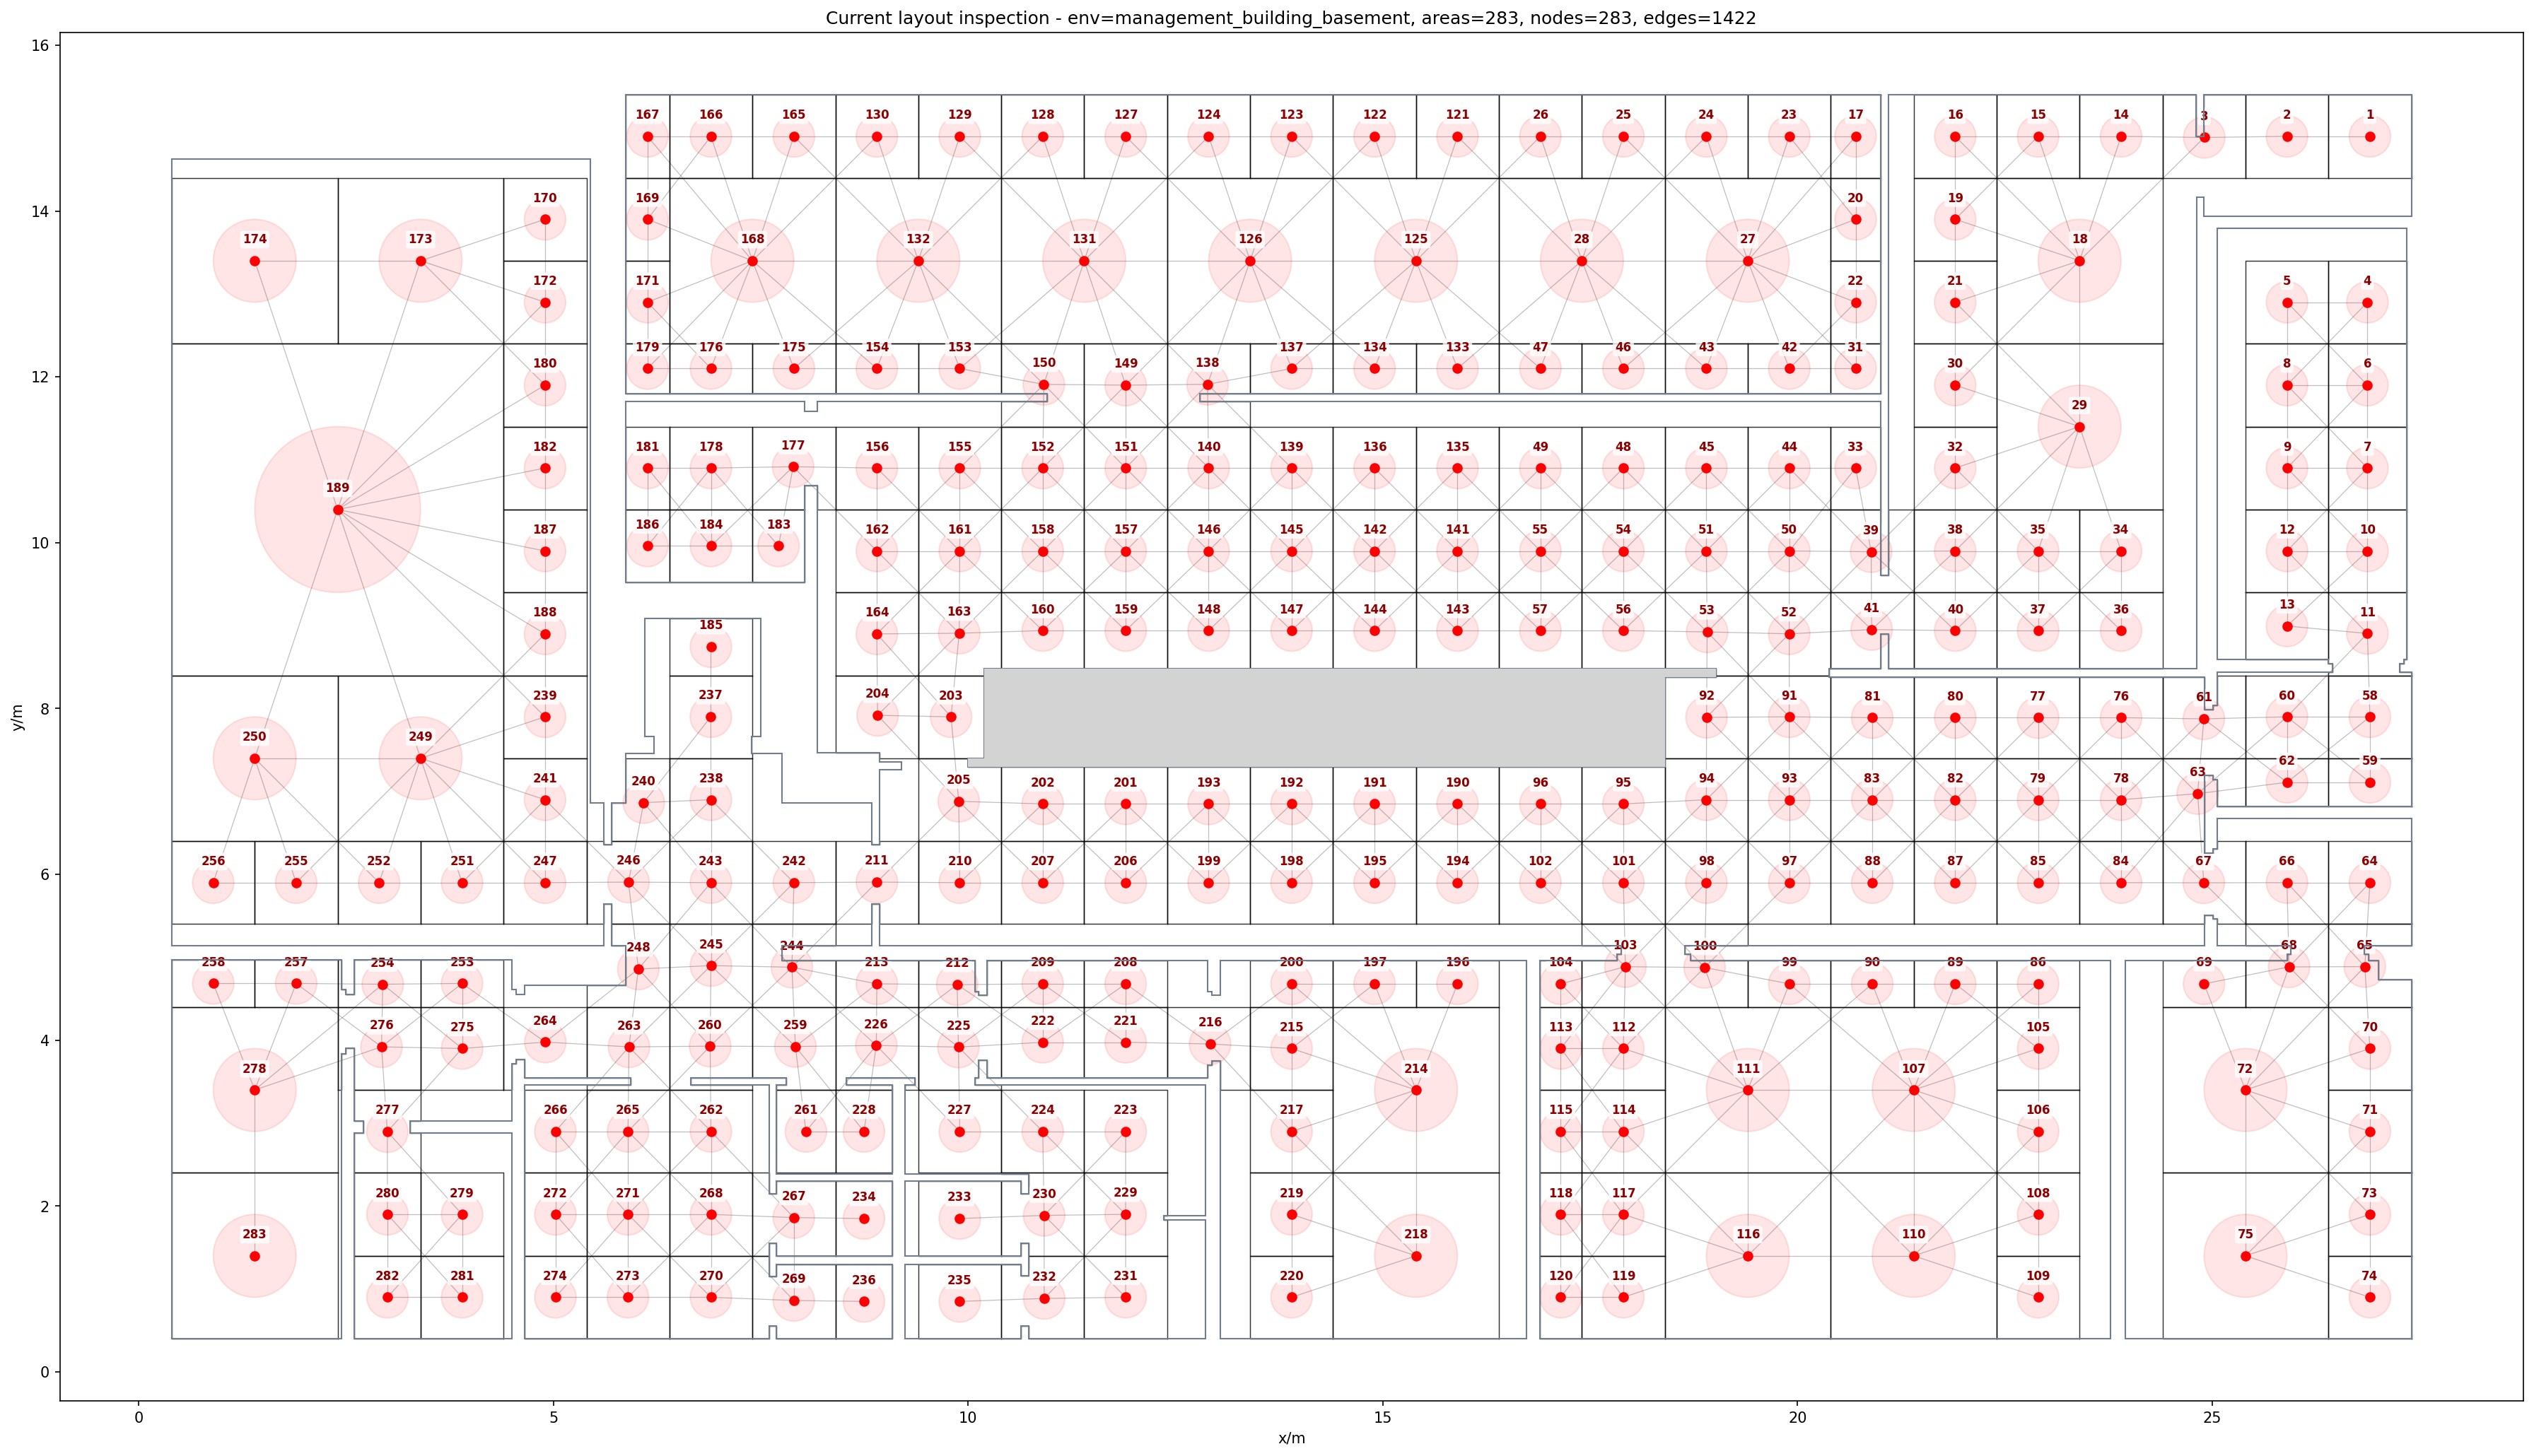

In [15]:
display(Image(filename=str(layout_images["basement"])))

In [16]:
with (LAYOUTS_DIR / "basement.json").open(encoding="utf-8") as f:
    basement_layout = json.load(f)

print("Claves del layout exportado:", list(basement_layout.keys()))
print(f"Nº de waypoints: {len(basement_layout['waypoints'])}")
print("Nodo '278' (source usado en configs/management_building.yaml):")
print(basement_layout["waypoints"]["278"])

Claves del layout exportado: ['metadata', 'waypoints', 'specific_areas', 'nodes', 'edges', 'target_nodes']
Nº de waypoints: 283
Nodo '278' (source usado en configs/management_building.yaml):
[[1.4000000000000001, 3.4], 0.5]


## Restricción importante: agentes vs. capacidad de nodo

Cada nodo tiene una capacidad máxima (`node_capacity`) basada en el área de
la celda. Al configurar `agents`, el número de agentes para cada source
**no puede superar su `node_capacity`**.

Como regla práctica: `agents ≤ node_capacity * 0.7` asegura que JuPedSim
pueda colocar todos los agentes sin errores.

Este notebook ya tiene `src/` en el `sys.path` (ver celda de Setup), así
que podemos consultar la capacidad directamente con
`select_environment`, sin pasar por un subproceso:

In [17]:
from evac_sim.envs.environment_factory import select_environment

env = select_environment("management_building_basement")

for node_id in ["278", "27", "111", "5", "174"]:
    cap = env.graph.nodes[node_id]["node_capacity"]
    area = env.specific_areas[node_id].area
    print(f"node {node_id}: area={area:.2f}m2, capacity={cap}, agents<=0.7*cap -> {int(cap * 0.7)}")

node 278: area=4.00m2, capacity=8, agents<=0.7*cap -> 5
node 27: area=4.00m2, capacity=8, agents<=0.7*cap -> 5
node 111: area=4.00m2, capacity=8, agents<=0.7*cap -> 5
node 5: area=1.00m2, capacity=2, agents<=0.7*cap -> 1
node 174: area=4.00m2, capacity=8, agents<=0.7*cap -> 5


## Flujo completo para la interfaz

```
1. Usuario configura parámetros:
   - Escenario (basement / floor_0 / floor_1) o escenario personalizado
   - Sources y nº de agentes por source
   - Targets
   - mode_type, gamma, velocidades, riesgo (semilla es opcional)

2. Interfaz construye el YAML mínimo con esos parámetros y lo guarda en un fichero temporal

3. Interfaz llama a validate_scenario_config --output <ruta_validated.yaml>:
   → Si INVALID: mostrar errores al usuario y detener
   → Si VALID:   el YAML normalizado (con semilla auto-asignada si faltaba) queda listo

4. Interfaz llama a run_scenario --config <ruta_validated.yaml>:
   → Espera hasta que termine (18–60 s típicamente)
   → Lee result.json del output-dir

5. Interfaz muestra:
   - summary.evacuation_time
   - summary.average_evacuation_time
   - summary.groups[] (métricas por grupo)
   - agents.csv (tabla de agentes)
   - Imágenes PNG de trayectorias y densidad
```

### Ejemplo de integración en Python

Las mismas funciones que propone `MANAGEMENT_BUILDING_API.md`, adaptadas a
las rutas reales de este notebook (`EVAC_SIM`, `GEN_CONFIG_DIR`,
`OUTPUT_ROOT`). `run_simulation` ya quedó demostrado en el Paso 2 (todas
las corridas de este notebook pasan por el mismo patrón de subproceso), así
que aquí solo volvemos a invocar `generate_and_validate` — es la parte más
barata y la que de verdad decide si la interfaz puede seguir adelante.

In [18]:
def generate_and_validate(scenario_name: str, config: dict, validated_yaml_path: Path) -> tuple[bool, list[str]]:
    """Write the minimal config to YAML, call `evac-sim validate --output` and
    return (is_valid, warnings)."""
    tmp_path = GEN_CONFIG_DIR / f"{scenario_name}_input.yaml"
    with tmp_path.open("w", encoding="utf-8") as f:
        yaml.safe_dump({scenario_name: config}, f, allow_unicode=True, sort_keys=False)

    result = subprocess.run(
        [str(EVAC_SIM), "validate",
         "--config", str(tmp_path),
         "--scenario", scenario_name,
         "--output", str(validated_yaml_path)],
        cwd=PROJECT_ROOT, capture_output=True, text=True,
    )

    is_valid = result.returncode == 0
    warnings = [
        line.strip().lstrip("- ")
        for line in result.stdout.splitlines()
        if line.strip().startswith("- ")
    ]
    return is_valid, warnings


def run_simulation(validated_yaml_path: Path, scenario_name: str, output_dir: Path) -> dict:
    """Run the simulation from the generated YAML and return result.json."""
    subprocess.run(
        [str(EVAC_SIM), "run",
         "--config", str(validated_yaml_path),
         "--scenario", scenario_name,
         "--output-dir", str(output_dir),
         "--output-format", "json,csv,html"],
        cwd=PROJECT_ROOT, check=True,
    )
    with (output_dir / "result.json").open(encoding="utf-8") as f:
        return json.load(f)


is_valid, warnings = generate_and_validate(
    "mi_escenario", mi_escenario_config, GEN_CONFIG_DIR / "mi_escenario_validated_v2.yaml"
)
print(f"is_valid: {is_valid}")
print(f"warnings: {warnings}")

is_valid: True
warnings: ["'master_seed' was missing; assigned random seed 689966."]


## Resumen

Este notebook ejecutó, de punta a punta, todo el flujo descrito en
`MANAGEMENT_BUILDING_API.md`:

- `evac-sim validate` sobre un YAML mínimo (con `--output` como generador
  de config) y sobre los tres escenarios reales de
  `configs/management_building.yaml`.
- `evac-sim run` para `basement`, `floor_0`, `floor_1` y `mi_escenario`
  (`--heuristic`/`--horizon-k` quedaron documentados con el comando exacto
  a usar, sin ejecutarlos, para no añadir varios minutos más).
- `evac-sim inspect` en modo headless para los tres entornos.
- Lectura de todos los artefactos de salida: `result.json`, `summary.csv`,
  `agents.csv`, `experiment_metrics.csv`, las bases de datos SQLite de
  trayectorias y las animaciones HTML.

Todos los artefactos generados quedaron bajo `runs/notebook_api_demo/`
(ignorado por git) y los YAML mínimos bajo `configs/notebook_generated/`
(también ignorado por git).